# Tokenizer generations

固定测试文本，对DeepSeek各代及Claude、OpenAI、Mistral、Qwen tokenizer
计算六组intrinsic指标：

1. 压缩率：tokens / 1k UTF-8 bytes；原始tokens / 1k codepoints仍保存在CSV
2. fallback：incomplete UTF-8 mass、其中depth≤1的shallow fallback mass
3. BPE结构：先区分UTF-8完整性，再对完整token按depth分桶
4. Shannon entropy：token一元分布的不确定性及其归一化efficiency
5. Rényi efficiency：固定α=2.5，更强调头部高频token
6. 词表利用：active types，以及前100万输出token的标准化active types

自然语言是English/French/Chinese/Japanese × Wikipedia/Web八个case；
Code另有Python、TypeScript、Bash三个case，统一来自CodeParrot GitHub Code。
默认每个case取1个100 MB shard；需要复查稳定性时把`NUM_SHARDS`改回3。
同一个shard在一次遍历中同时交给所有tokenizer。
2023对照组为DeepSeek 7B、Claude 2.1、OpenAI cl100k和Qwen-7B；
DeepSeek V3、o200k和Tekken是现代对照组；Qwen3沿用Qwen-7B词表。

OpenAI的`cl100k_base`是2023年GPT-4 / GPT-4 Turbo的同期对照；
`o200k_base`是GPT-4o时期开始使用的现代对照。


## 指标、公式与目的

设测试集共输出$N$个token，UTF-8字节数为$B$，Unicode codepoint数为$C$，
第$i$个token的出现次数和概率分别为$c_i$、$p_i=c_i/N$。

| 组别 | 指标 | 目的与解释 |
|---|---|---|
| 压缩率 | `tokens_per_1000_bytes` $=1000N/B$ | 衡量处理固定UTF-8字节数需要多少token；越低，序列越短。主图使用这一指标，因为它可以精确实现按输入字节预算的比较。 |
| 压缩率 | `tokens_per_1000_codepoints` $=1000N/C$ | 衡量处理固定Unicode codepoint数需要多少token。一个常规汉字是1个codepoint，但在UTF-8中通常占3 bytes；把中文该指标除以3，只是近似换算为$1000N/B$，不是更好的“字符校正”。由于真实语料还含ASCII、标点等，$B/C$也不严格等于3。该原始值保存在CSV，不再单独画主图。 |
| fallback | `incomplete_utf8_mass` | 输出token中，自身byte sequence不能独立解码为UTF-8的概率质量。它表示分词边界落入字符内部的程度，不表示原文损坏。越高，越依赖byte-level fallback。 |
| fallback | `shallow_fallback_mass` | `incomplete_utf8_mass`中depth≤1的部分，用于区分直接或浅层byte fallback与更深merge形成的不完整token。它是诊断项，不单独充当质量总分。 |
| 结构 | completeness-aware depth distribution | 先区分UTF-8是否完整，再统计完整token的depth=0、1、2、3–4、5–6、7+概率质量。目的是描述输出token在BPE merge树中的结构来源；depth高低本身不等于好坏。 |
| 结构 | `complete_utf8_mass` | 输出流中UTF-8完整且属于BPE的token mass。普通文本中它通常约等于$1-\text{incomplete\_utf8\_mass}$。 |
| 结构 | `complete_mean_depth` | 只在UTF-8完整的BPE token上按输出次数加权计算平均depth。它描述成功分词部分使用了多深的merge结构，不受incomplete token直接拉低。 |
| 分布 | `shannon_entropy_bits` $=-\sum_i p_i\log_2p_i$ | 传统Shannon entropy，衡量token一元分布整体的不确定性。它同时受概率形状和词表规模影响，原始值不宜直接作为不同词表大小之间的质量排名。 |
| 分布 | `shannon_model_efficiency` $=H_1/\log_2|V|$ | 用完整BPE模型词表大小归一化Shannon entropy，便于比较不同大小词表的分布均匀程度；高值表示使用更分散，不自动等于模型效果更好。 |
| 分布 | `renyi_model_efficiency` $=H_{2.5}/\log_2|V|$ | Rényi entropy在α=2.5时比Shannon更强调高频头部。用于诊断概率是否过度集中；这是相关性指标，不是已经证明的tokenizer质量函数。 |
| 词表利用 | `active_model_ratio` | 整个评测集内至少输出一次的BPE token数除以模型BPE词表大小。用于发现从未被当前语言/领域使用的词表容量，但高度依赖测试集规模。 |
| 词表利用 | `standardized_active_ratio` | 只看前100万个输出token的active types，再除以模型词表大小。目的是控制观察token数量；主图使用这一版本。它仍然描述利用率，不代表unused token一定无用。 |

`bytes_per_token`与`codepoints_per_token`是两个压缩率指标的倒数形式；
`shannon_effective_types=2^{H_1}`和`renyi_effective_types=2^{H_{2.5}}`把熵换算成
“等概率token的等效数量”。这些值保存在CSV中作为解释辅助，不再单独增加主图。


In [118]:
%pip install -q "tokenizers==0.22.2" "tiktoken==0.12.0" "datasets>=4.0" "huggingface-hub>=1.0" "pandas>=2.2" "matplotlib>=3.8"


Note: you may need to restart the kernel to use updated packages.


In [119]:
from collections import Counter
from pathlib import Path
import base64
import importlib.util
import json
import math
import shutil
import unicodedata
import urllib.request

import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import numpy as np
import pandas as pd
import tiktoken
from datasets import load_dataset
from huggingface_hub import hf_hub_download
from IPython.display import display
from tokenizers import Tokenizer

IN_COLAB = importlib.util.find_spec("google.colab") is not None

# 本地存在结果包时自动进入绘图/分析模式；设为None即从头运行完整统计。
RESULTS_SOURCE = Path.home() / "Downloads/tokenizer_generation_analysis.zip"
# RESULTS_SOURCE = None
if IN_COLAB or not RESULTS_SOURCE.exists():
    RESULTS_SOURCE = None

RUN_EVALUATION = RESULTS_SOURCE is None
OUTPUT_DIR = Path("/content/tokenizer_generation_analysis") if IN_COLAB else Path.cwd() / "tokenizer_generation_analysis"
if RESULTS_SOURCE is not None and RESULTS_SOURCE.is_dir():
    OUTPUT_DIR = RESULTS_SOURCE
elif RESULTS_SOURCE is not None:
    OUTPUT_DIR = RESULTS_SOURCE.with_suffix("")
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    shutil.unpack_archive(str(RESULTS_SOURCE), OUTPUT_DIR)
else:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

FREQUENCY_DIR = OUTPUT_DIR / "frequencies"
PLOT_DIR = OUTPUT_DIR / "plots"
for path in (OUTPUT_DIR, FREQUENCY_DIR, PLOT_DIR):
    path.mkdir(parents=True, exist_ok=True)

EVAL_BYTES = 100_000_000
# 先前用3个独立的100 MB shard验证过主要指标稳定，因此默认只跑1个；
# 若要重新检查shard方差，将这里改为3。
NUM_SHARDS = 1
SHARDS = tuple("abc"[:NUM_SHARDS])
ACTIVE_SAMPLE_TOKENS = 1_000_000
RENYI_ALPHA = 2.5
SHUFFLE_SEED = 42
SHUFFLE_BUFFER = 2_000
LOG_EVERY_BYTES = 10_000_000

MODEL_SPECS = {
    "deepseek_7b": ("hf", "deepseek-ai/deepseek-llm-7b-base"),
    "deepseek_v2_lite": ("hf", "deepseek-ai/DeepSeek-V2-Lite"),
    "deepseek_v3_base": ("hf", "deepseek-ai/DeepSeek-V3-Base"),
    "deepseek_v3_2": ("hf", "deepseek-ai/DeepSeek-V3.2"),
    "deepseek_v4_flash_base": ("hf", "deepseek-ai/DeepSeek-V4-Flash-Base"),
    "claude_2_1": ("claude", "https://unpkg.com/@anthropic-ai/tokenizer@0.0.4/claude.json"),
    "openai_cl100k": ("tiktoken", "cl100k_base"),
    "openai_o200k": ("tiktoken", "o200k_base"),
    "mistral_tekken": ("tekken", "mistralai/Mistral-Nemo-Base-2407"),
    "qwen_7b": ("qwen1", "Qwen/Qwen-7B"),
    "qwen3": ("hf", "Qwen/Qwen3-8B-Base"),
}
MODEL_ORDER = list(MODEL_SPECS)
# Qwen-7B与Qwen3的普通token、ID、normalizer和pre-tokenizer均已逐项验证一致。
KNOWN_EQUIVALENTS = {"qwen3": "qwen_7b"}
MODEL_LABELS = {"qwen_7b": "qwen_7b / qwen3"}

CODE_DATASET = "ruediste/codeparrot-github-code-10G"

CASES = {
    "en_wiki": {
        "loader": "parquet",
        "data_files": "hf://datasets/wikimedia/wikipedia@refs/convert/parquet/20231101.en/train/*.parquet",
        "field": "text",
    },
    "en_web": {
        "dataset": "HuggingFaceFW/fineweb",
        "config": "sample-10BT",
        "field": "text",
    },
    "fr_wiki": {
        "loader": "parquet",
        "data_files": "hf://datasets/wikimedia/wikipedia@refs/convert/parquet/20231101.fr/train/*.parquet",
        "field": "text",
    },
    "fr_web": {
        "dataset": "HuggingFaceFW/fineweb-2",
        "config": "fra_Latn",
        "field": "text",
    },
    "zh_wiki": {
        "loader": "parquet",
        "data_files": "hf://datasets/wikimedia/wikipedia@refs/convert/parquet/20231101.zh/train/*.parquet",
        "field": "text",
    },
    "zh_web": {
        "dataset": "HuggingFaceFW/fineweb-2",
        "config": "cmn_Hani",
        "field": "text",
    },
    "ja_wiki": {
        "loader": "parquet",
        "data_files": "hf://datasets/wikimedia/wikipedia@refs/convert/parquet/20231101.ja/train/*.parquet",
        "field": "text",
    },
    "ja_web": {
        "dataset": "HuggingFaceFW/fineweb-2",
        "config": "jpn_Jpan",
        "field": "text",
    },
    "code_python": {
        "dataset": CODE_DATASET,
        "config": "py",
        "field": "code",
    },
    "code_typescript": {
        "dataset": CODE_DATASET,
        "config": "ts",
        "field": "code",
    },
    "code_bash": {
        "dataset": CODE_DATASET,
        "config": "sh",
        "field": "code",
        "bash_only": True,
    },
}
CASE_ORDER = list(CASES)

print("mode:", "evaluate from scratch" if RUN_EVALUATION else f"load {RESULTS_SOURCE}")
print("output:", OUTPUT_DIR)
print("shards:", SHARDS)


mode: load /Users/tgbaggio/Downloads/tokenizer_generation_analysis.zip
output: /Users/tgbaggio/Downloads/tokenizer_generation_analysis
shards: ('a',)


## 1. 语料流

不缓存测试集，也不为每个tokenizer重复下载。每个case只建立一个流，按顺序切分shard；
每篇文档随即交给所有tokenizer，因此tokenizer之间使用的文本完全相同。

Python/TypeScript/Bash使用`ruediste/codeparrot-github-code-10G`：它是将官方
CodeParrot GitHub Code按语言转换成Parquet的社区版本，每种语言最多保留前10 GB。
这避免了官方仓库旧式loading script与当前`datasets`不兼容的问题。
`sh`配置同时包含sh/bash/zsh；`code_bash`只保留`.bash`文件或shebang明确包含`bash`的文件。


In [120]:
def corpus_stream(spec):
    if spec.get("loader") == "parquet":
        rows = load_dataset(
            "parquet", data_files=spec["data_files"], split="train", streaming=True
        )
    else:
        rows = load_dataset(
            spec["dataset"],
            name=spec.get("config"),
            data_dir=spec.get("data_dir"),
            split="train",
            streaming=True,
        )
    return iter(rows.shuffle(seed=SHUFFLE_SEED, buffer_size=SHUFFLE_BUFFER))


def next_text(rows, spec):
    while True:
        row = next(rows)
        text = row.get(spec["field"])
        if not text:
            continue
        if spec.get("bash_only"):
            first_line = text.partition("\n")[0].lower()
            path = row.get("path", "").lower()
            if not (
                path.endswith(".bash")
                or (first_line.startswith("#!") and "bash" in first_line)
            ):
                continue
        return text


## 2. 恢复BPE merge tree

DeepSeek/Qwen3使用ByteLevel BPE，Claude/OpenAI/Qwen-7B/Tekken使用字节级
mergeable ranks。两条路径最后都转换成同构的`raw_bytes / depth / kind`结构。


In [121]:
def byte_decoder():
    values = list(range(ord("!"), ord("~") + 1))
    values += list(range(ord("¡"), ord("¬") + 1))
    values += list(range(ord("®"), ord("ÿ") + 1))
    codepoints = values.copy()
    extra = 0
    for value in range(256):
        if value not in values:
            values.append(value)
            codepoints.append(256 + extra)
            extra += 1
    return {chr(codepoint): value for value, codepoint in zip(values, codepoints)}


BYTE_DECODER = byte_decoder()


def decode_bytes(raw):
    try:
        text = raw.decode("utf-8")
        return text, False, len(text)
    except UnicodeDecodeError:
        return raw.decode("utf-8", "replace"), True, None


def hf_bpe_structure(config):
    model = config["model"]
    vocab = model["vocab"]
    print("model type:", model["type"], "vocab:", f"{len(vocab):,}")

    # V3之后有少量协议字面token绕过ByteLevel BPE，
    # 例如包含`｜`的token；它们不属于merge tree。
    raw_bytes = {}
    for token, token_id in vocab.items():
        if all(char in BYTE_DECODER for char in token):
            raw_bytes[token_id] = bytes(BYTE_DECODER[char] for char in token)

    depths = {token_id: 0 for token_id in raw_bytes}
    children = {}
    for item in model["merges"]:
        left, right = item if isinstance(item, list) else item.split(" ", 1)
        merged_id = vocab[left + right]
        left_id, right_id = vocab[left], vocab[right]
        children[merged_id] = (left_id, right_id)
        depths[merged_id] = 1 + max(depths[left_id], depths[right_id])

    kinds = {
        token_id: (
            "merged" if token_id in children
            else "base" if token_id in raw_bytes
            else "literal_model"
        )
        for token_id in vocab.values()
    }
    for item in config.get("added_tokens", []):
        kinds[item["id"]] = "special" if item.get("special") else "added"
    return {"raw_bytes": raw_bytes, "depth": depths, "kind": kinds}


def parse_claude_ranks(config):
    _, offset, *tokens = config["bpe_ranks"].split()
    offset = int(offset)
    return {
        base64.b64decode(token): offset + index
        for index, token in enumerate(tokens)
    }


def parse_tiktoken_ranks(path):
    return {
        base64.b64decode(token): int(rank)
        for token, rank in (
            line.split() for line in Path(path).read_bytes().splitlines() if line
        )
    }


def parts_before_rank(token, ranks, max_rank):
    parts = [bytes([value]) for value in token]
    while len(parts) > 1:
        candidates = [
            (ranks.get(parts[i] + parts[i + 1], max_rank), i)
            for i in range(len(parts) - 1)
        ]
        rank, index = min(candidates)
        if rank == max_rank:
            break
        parts[index:index + 2] = [parts[index] + parts[index + 1]]
    return parts


def ranked_bpe_structure(ranks, special_tokens=None):
    special_tokens = special_tokens or {}
    raw_bytes = {token_id: raw for raw, token_id in ranks.items()}
    depths, children = {}, {}
    for raw, token_id in sorted(ranks.items(), key=lambda item: item[1]):
        if len(raw) == 1:
            depths[token_id] = 0
            continue
        left, right = parts_before_rank(raw, ranks, token_id)
        left_id, right_id = ranks[left], ranks[right]
        children[token_id] = (left_id, right_id)
        depths[token_id] = 1 + max(depths[left_id], depths[right_id])

    kinds = {
        token_id: "merged" if token_id in children else "base"
        for token_id in raw_bytes
    }
    kinds.update({token_id: "special" for token_id in special_tokens.values()})
    return {"raw_bytes": raw_bytes, "depth": depths, "kind": kinds}


In [122]:
class HuggingFaceAdapter:
    def __init__(self, path):
        self.path = Path(path)
        self.config = json.loads(self.path.read_text(encoding="utf-8"))
        self.tokenizer = Tokenizer.from_file(str(self.path))
        self.structure = hf_bpe_structure(self.config)
        self.model_vocab = sum(
            kind in {"base", "merged"}
            for kind in self.structure["kind"].values()
        )
        self.total_vocab = self.tokenizer.get_vocab_size(with_added_tokens=True)
        # plain-text等价性只看真正参与普通编码的模型、normalizer和pre-tokenizer；
        # special-token协议变化不重复跑普通文本。
        self.plain_pipeline = {
            key: self.config.get(key)
            for key in ("model", "normalizer", "pre_tokenizer")
        }

    def encode(self, text):
        return self.tokenizer.encode(text, add_special_tokens=False).ids

    def token_info(self, token_id):
        raw = self.structure["raw_bytes"].get(token_id)
        if raw is None:
            decoded = self.tokenizer.decode([token_id], skip_special_tokens=False)
            return decoded, self.structure["kind"].get(token_id, "added"), None, None, False, len(decoded)
        decoded, incomplete, codepoints = decode_bytes(raw)
        return (
            decoded,
            self.structure["kind"][token_id],
            self.structure["depth"][token_id],
            len(raw),
            incomplete,
            codepoints,
        )


class ClaudeAdapter:
    def __init__(self, path):
        self.path = Path(path)
        config = json.loads(self.path.read_text(encoding="utf-8"))
        self.ranks = parse_claude_ranks(config)
        self.special_tokens = config["special_tokens"]
        self.special_by_id = {token_id: token for token, token_id in self.special_tokens.items()}
        self.encoding = tiktoken.Encoding(
            name="claude_2_1",
            pat_str=config["pat_str"],
            mergeable_ranks=self.ranks,
            special_tokens=self.special_tokens,
        )
        self.structure = ranked_bpe_structure(self.ranks, self.special_tokens)
        self.model_vocab = len(self.ranks)
        self.total_vocab = self.encoding.n_vocab
        self.plain_pipeline = {"claude_pat_str": config["pat_str"], "ranks": self.ranks}
        print("model type: BPE vocab:", f"{self.model_vocab:,}")

    def encode(self, text):
        text = unicodedata.normalize("NFKC", text)
        return self.encoding.encode(text, allowed_special="all")

    def token_info(self, token_id):
        if token_id in self.special_by_id:
            token = self.special_by_id[token_id]
            return token, "special", None, None, False, len(token)
        raw = self.structure["raw_bytes"][token_id]
        decoded, incomplete, codepoints = decode_bytes(raw)
        return (
            decoded,
            self.structure["kind"][token_id],
            self.structure["depth"][token_id],
            len(raw),
            incomplete,
            codepoints,
        )


class TiktokenAdapter:
    def __init__(self, name):
        self.encoding = tiktoken.get_encoding(name)
        self.ranks = self.encoding._mergeable_ranks
        self.structure = ranked_bpe_structure(self.ranks, self.encoding._special_tokens)
        self.model_vocab = len(self.ranks)
        self.total_vocab = self.encoding.n_vocab
        self.plain_pipeline = {
            "pattern": self.encoding._pat_str,
            "ranks": self.ranks,
        }
        print("model type: BPE vocab:", f"{self.model_vocab:,}")

    def encode(self, text):
        return self.encoding.encode(text, disallowed_special=())

    def token_info(self, token_id):
        raw = self.structure["raw_bytes"][token_id]
        decoded, incomplete, codepoints = decode_bytes(raw)
        return (
            decoded,
            self.structure["kind"][token_id],
            self.structure["depth"][token_id],
            len(raw),
            incomplete,
            codepoints,
        )


class Qwen1Adapter:
    PATTERN = r"""(?i:'s|'t|'re|'ve|'m|'ll|'d)|[^\r\n\p{L}\p{N}]?\p{L}+|\p{N}| ?[^\s\p{L}\p{N}]+[\r\n]*|\s*[\r\n]+|\s+(?!\S)|\s+"""

    def __init__(self, path):
        self.ranks = parse_tiktoken_ranks(path)
        names = ["<|endoftext|>", "<|im_start|>", "<|im_end|>"]
        names += [f"<|extra_{index}|>" for index in range(205)]
        self.special_tokens = {
            token: 151643 + index for index, token in enumerate(names)
        }
        self.special_by_id = {
            token_id: token for token, token_id in self.special_tokens.items()
        }
        self.encoding = tiktoken.Encoding(
            name="qwen_7b",
            pat_str=self.PATTERN,
            mergeable_ranks=self.ranks,
            special_tokens=self.special_tokens,
        )
        self.structure = ranked_bpe_structure(self.ranks, self.special_tokens)
        self.model_vocab = len(self.ranks)
        self.total_vocab = self.encoding.n_vocab
        self.plain_pipeline = {
            "normalizer": "NFC",
            "pattern": self.PATTERN,
            "ranks": self.ranks,
        }
        print("model type: BPE vocab:", f"{self.model_vocab:,}")

    def encode(self, text):
        text = unicodedata.normalize("NFC", text)
        return self.encoding.encode(text, allowed_special="all")

    def token_info(self, token_id):
        if token_id in self.special_by_id:
            token = self.special_by_id[token_id]
            return token, "special", None, None, False, len(token)
        raw = self.structure["raw_bytes"][token_id]
        decoded, incomplete, codepoints = decode_bytes(raw)
        return (
            decoded,
            self.structure["kind"][token_id],
            self.structure["depth"][token_id],
            len(raw),
            incomplete,
            codepoints,
        )


class TekkenAdapter:
    def __init__(self, path):
        config = json.loads(Path(path).read_text(encoding="utf-8"))
        self.num_special_tokens = config["config"]["default_num_special_tokens"]
        self.total_vocab = config["config"]["default_vocab_size"]
        self.model_vocab = self.total_vocab - self.num_special_tokens
        vocab = config["vocab"][:self.model_vocab]
        self.inner_ranks = {
            base64.b64decode(token["token_bytes"]): token["rank"]
            for token in vocab
        }
        shifted_ranks = {
            raw: rank + self.num_special_tokens
            for raw, rank in self.inner_ranks.items()
        }
        self.encoding = tiktoken.Encoding(
            name="mistral_tekken",
            pat_str=config["config"]["pattern"],
            mergeable_ranks=self.inner_ranks,
            special_tokens={},
        )
        self.structure = ranked_bpe_structure(shifted_ranks)
        self.plain_pipeline = {
            "pattern": config["config"]["pattern"],
            "ranks": self.inner_ranks,
        }
        print("model type: BPE vocab:", f"{self.model_vocab:,}")

    def encode(self, text):
        return [token_id + self.num_special_tokens for token_id in self.encoding.encode(text)]

    def token_info(self, token_id):
        raw = self.structure["raw_bytes"][token_id]
        decoded, incomplete, codepoints = decode_bytes(raw)
        return (
            decoded,
            self.structure["kind"][token_id],
            self.structure["depth"][token_id],
            len(raw),
            incomplete,
            codepoints,
        )


## 3. 下载tokenizer，并识别plain-text等价版本

这里直接比较配置内容，不计算文件hash。若两代模型只有special token / 消息协议变化，
普通文本只计算一次，最后把指标映射回所有模型名称。


In [123]:
TOKENIZER_DIR = OUTPUT_DIR / "tokenizers"
TOKENIZER_DIR.mkdir(exist_ok=True)

if RUN_EVALUATION:
    adapters = {}
    for name, (kind, source) in MODEL_SPECS.items():
        print("\nloading", name)
        if kind == "hf":
            path = hf_hub_download(source, "tokenizer.json")
            adapters[name] = HuggingFaceAdapter(path)
        elif kind == "claude":
            path = TOKENIZER_DIR / "claude_2_1.json"
            if not path.exists():
                urllib.request.urlretrieve(source, path)
            adapters[name] = ClaudeAdapter(path)
        elif kind == "tiktoken":
            adapters[name] = TiktokenAdapter(source)
        elif kind == "qwen1":
            path = hf_hub_download(source, "qwen.tiktoken")
            adapters[name] = Qwen1Adapter(path)
        else:
            path = hf_hub_download(source, "tekken.json")
            adapters[name] = TekkenAdapter(path)

    canonical_of = {}
    canonical_models = []
    for name in MODEL_ORDER:
        equivalent = KNOWN_EQUIVALENTS.get(name) or next(
            (
                previous
                for previous in canonical_models
                if adapters[name].plain_pipeline == adapters[previous].plain_pipeline
            ),
            None,
        )
        canonical_of[name] = equivalent or name
        if equivalent is None:
            canonical_models.append(name)

    manifest_df = pd.DataFrame([
        {
            "tokenizer": name,
            "source": MODEL_SPECS[name][1],
            "model_vocab": adapters[name].model_vocab,
            "total_vocab": adapters[name].total_vocab,
            "plain_text_equivalent_to": canonical_of[name],
        }
        for name in MODEL_ORDER
    ])
    manifest_df.to_csv(OUTPUT_DIR / "tokenizer_manifest.csv", index=False)
else:
    manifest_df = pd.read_csv(OUTPUT_DIR / "tokenizer_manifest.csv")
    canonical_of = manifest_df.set_index("tokenizer")["plain_text_equivalent_to"].to_dict()
    canonical_of.update(KNOWN_EQUIVALENTS)
    manifest_df["plain_text_equivalent_to"] = manifest_df["tokenizer"].map(canonical_of)
    canonical_models = list(dict.fromkeys(canonical_of[name] for name in MODEL_ORDER))

display(manifest_df)
print("实际需要运行的tokenizer：", canonical_models)


,tokenizer,source,model_vocab,total_vocab,plain_text_equivalent_to
0,deepseek_7b,deepseek-ai/deepseek-llm-7b-base,100000,100015,deepseek_7b
1,deepseek_v2_lite,deepseek-ai/DeepSeek-V2-Lite,100000,100002,deepseek_7b
2,deepseek_v3_base,deepseek-ai/DeepSeek-V3-Base,127997,128815,deepseek_v3_base
3,deepseek_v3_2,deepseek-ai/DeepSeek-V3.2,127997,128815,deepseek_v3_base
4,deepseek_v4_flash_base,deepseek-ai/DeepSeek-V4-Flash-Base,127997,129280,deepseek_v3_base
5,claude_2_1,https://unpkg.com/@anthropic-ai/tokenizer@0.0....,64995,65000,claude_2_1
6,openai_cl100k,cl100k_base,100256,100277,openai_cl100k
7,openai_o200k,o200k_base,199998,200019,openai_o200k
8,mistral_tekken,mistralai/Mistral-Nemo-Base-2407,130072,131072,mistral_tekken
9,qwen_7b,Qwen/Qwen-7B,151643,151851,qwen_7b


实际需要运行的 unique tokenizer: ['deepseek_7b', 'deepseek_v3_base', 'claude_2_1', 'openai_cl100k', 'openai_o200k', 'mistral_tekken', 'qwen_7b', 'qwen3']


## 4. Token的互斥结构分类

判定顺序很重要：先看UTF-8是否完整，再对完整token直接按depth分桶。
depth 0/1的incomplete token是主要fallback；少量更深的incomplete token单列，避免丢失质量。


In [124]:
STRUCTURE_ORDER = [
    "incomplete_depth01",
    "incomplete_depth2plus",
    "depth0_normal",
    "depth1_normal",
    "depth2",
    "depth3_4",
    "depth5_6",
    "depth7plus",
    "non_bpe",
]


def structural_class(row):
    if row["kind"] not in {"base", "merged"}:
        return "non_bpe"
    if row["incomplete_utf8"]:
        return "incomplete_depth01" if row["depth"] <= 1 else "incomplete_depth2plus"
    if row["depth"] == 0:
        return "depth0_normal"
    if row["depth"] == 1:
        return "depth1_normal"
    if row["depth"] == 2:
        return "depth2"
    if row["depth"] <= 4:
        return "depth3_4"
    if row["depth"] <= 6:
        return "depth5_6"
    return "depth7plus"


def depth_bin(depth):
    if pd.isna(depth):
        return "non_bpe"
    depth = int(depth)
    if depth <= 2:
        return str(depth)
    if depth <= 4:
        return "3-4"
    if depth <= 6:
        return "5-6"
    return "7+"


def frequency_frame(adapter, counts):
    total = sum(counts.values())
    rows = []
    for rank, (token_id, count) in enumerate(counts.most_common(), start=1):
        decoded, kind, depth, token_bytes, incomplete, codepoints = adapter.token_info(token_id)
        rows.append({
            "rank": rank,
            "token_id": token_id,
            "decoded": decoded,
            "kind": kind,
            "depth": depth,
            "token_bytes": token_bytes,
            "codepoints": codepoints,
            "incomplete_utf8": incomplete,
            "count": count,
            "probability": count / total,
        })
    frame = pd.DataFrame(rows)
    frame["structural_class"] = frame.apply(structural_class, axis=1)
    frame["depth_bin"] = frame["depth"].map(depth_bin)
    return frame


## 5. 由一张frequency table派生全部指标


In [125]:
def renyi_entropy(probabilities, alpha=RENYI_ALPHA):
    return math.log2(math.fsum(p**alpha for p in probabilities)) / (1 - alpha)


def shannon_entropy(probabilities):
    return -math.fsum(p * math.log2(p) for p in probabilities if p > 0)


def summarize_frequency(frame, adapter, corpus, sample_counts):
    total_tokens = int(frame["count"].sum())
    probabilities = frame["probability"].to_numpy()
    shannon = shannon_entropy(probabilities)
    renyi = renyi_entropy(probabilities)
    bpe = frame[frame["kind"].isin(["base", "merged"])]

    structure = (
        frame.groupby("structural_class", observed=True)
        .agg(active_types=("token_id", "size"), emitted_tokens=("count", "sum"))
        .reindex(STRUCTURE_ORDER, fill_value=0)
        .reset_index()
    )
    structure["probability_mass"] = structure["emitted_tokens"] / total_tokens

    depth = (
        bpe.groupby(["depth", "depth_bin"], observed=True)
        .agg(active_types=("token_id", "size"), emitted_tokens=("count", "sum"))
        .reset_index()
    )
    depth["probability_mass"] = depth["emitted_tokens"] / total_tokens

    joint = (
        bpe.groupby(
            ["depth", "depth_bin", "token_bytes", "codepoints", "incomplete_utf8"],
            dropna=False,
            observed=True,
        )
        .agg(active_types=("token_id", "size"), emitted_tokens=("count", "sum"))
        .reset_index()
    )
    joint["probability_mass"] = joint["emitted_tokens"] / total_tokens

    mass = structure.set_index("structural_class")["probability_mass"]
    sample_size = sum(sample_counts.values())
    summary = {
        **corpus,
        "final_tokens": total_tokens,
        "tokens_per_1000_bytes": 1000 * total_tokens / corpus["utf8_bytes"],
        "tokens_per_1000_codepoints": 1000 * total_tokens / corpus["codepoints"],
        "bytes_per_token": corpus["utf8_bytes"] / total_tokens,
        "codepoints_per_token": corpus["codepoints"] / total_tokens,
        "shannon_entropy_bits": shannon,
        "shannon_effective_types": 2**shannon,
        "shannon_model_efficiency": shannon / math.log2(adapter.model_vocab),
        "shannon_active_efficiency": shannon / math.log2(len(frame)),
        "renyi_alpha": RENYI_ALPHA,
        "renyi_entropy_bits": renyi,
        "renyi_effective_types": 2**renyi,
        "renyi_model_efficiency": renyi / math.log2(adapter.model_vocab),
        "renyi_active_efficiency": renyi / math.log2(len(frame)),
        "active_types": len(frame),
        "active_model_types": len(bpe),
        "active_model_ratio": len(bpe) / adapter.model_vocab,
        "standardized_sample_tokens": sample_size,
        "standardized_active_types": len(sample_counts),
        "standardized_active_ratio": len(sample_counts) / adapter.model_vocab,
        "incomplete_utf8_mass": mass["incomplete_depth01"] + mass["incomplete_depth2plus"],
        "shallow_fallback_mass": mass["incomplete_depth01"],
        "deep_incomplete_mass": mass["incomplete_depth2plus"],
        "depth0_normal_mass": mass["depth0_normal"],
        "depth1_normal_mass": mass["depth1_normal"],
        "depth2_mass": mass["depth2"],
        "depth3_4_mass": mass["depth3_4"],
        "depth5_6_mass": mass["depth5_6"],
        "depth7plus_mass": mass["depth7plus"],
    }
    return summary, structure, depth, joint


def prefix_sample_update(counter, used, token_ids):
    take = min(ACTIVE_SAMPLE_TOKENS - used, len(token_ids))
    if take > 0:
        counter.update(token_ids[:take])
    return used + take


MAIN_METRICS = [
    "tokens_per_1000_codepoints",
    "tokens_per_1000_bytes",
    "incomplete_utf8_mass",
    "shallow_fallback_mass",
    "complete_utf8_mass",
    "complete_mean_depth",
    "shannon_entropy_bits",
    "shannon_model_efficiency",
    "renyi_model_efficiency",
    "standardized_active_ratio",
]


def attach_complete_depth_metrics(summary, joint):
    keys = ["case", "shard", "tokenizer", "canonical"]
    complete = joint[(~joint["incomplete_utf8"]) & joint["depth"].notna()].copy()
    complete["weighted_depth_tokens"] = (
        complete["depth"] * complete["emitted_tokens"]
    )
    aggregate = (
        complete.groupby(keys, observed=True)
        .agg(
            complete_emitted_tokens=("emitted_tokens", "sum"),
            weighted_depth_tokens=("weighted_depth_tokens", "sum"),
        )
        .reset_index()
    )
    aggregate["complete_mean_depth"] = (
        aggregate["weighted_depth_tokens"] / aggregate["complete_emitted_tokens"]
    )
    summary = summary.drop(
        columns=["complete_utf8_mass", "complete_mean_depth"], errors="ignore"
    ).merge(aggregate[keys + ["complete_emitted_tokens", "complete_mean_depth"]], on=keys)
    summary["complete_utf8_mass"] = (
        summary["complete_emitted_tokens"] / summary["final_tokens"]
    )
    return summary.drop(columns="complete_emitted_tokens")


def visible_token(row):
    if row["incomplete_utf8"]:
        return f"<fragment id={int(row['token_id'])}, {int(row['token_bytes'])}B>"
    value = "" if pd.isna(row["decoded"]) else str(row["decoded"])
    return repr(value)


def build_top_tokens(model_names):
    rows = []
    for case in CASE_ORDER:
        for name in model_names:
            frame = pd.read_csv(FREQUENCY_DIR / f"{case}__{name}.csv.gz")
            row = {"case": case, "tokenizer": name}
            groups = {
                "top": frame.head(10),
                "multi_top": frame[
                    (~frame["incomplete_utf8"]) & frame["codepoints"].ge(2)
                ].head(10),
            }
            for prefix, tokens in groups.items():
                for rank, (_, token) in enumerate(tokens.iterrows(), start=1):
                    row[f"{prefix}_{rank}"] = (
                        f"{visible_token(token)} ({token['probability']:.2%})"
                    )
            rows.append(row)
    return pd.DataFrame(rows)


def build_entropy_stability(summary, model_names):
    pooled = summary[summary["shard"] == "pooled"]
    rows = []
    for name in model_names:
        table = pooled[pooled["tokenizer"] == name].set_index("case")
        row = {"tokenizer": name}
        paired_scores = []
        for metric, label in (
            ("shannon_entropy_bits", "shannon"),
            ("renyi_model_efficiency", "renyi"),
        ):
            changes = []
            for language in ("en", "fr", "zh", "ja"):
                wiki = table.loc[f"{language}_wiki", metric]
                web = table.loc[f"{language}_web", metric]
                changes.append(abs(wiki - web) / ((wiki + web) / 2))
            paired_change = sum(changes) / len(changes)
            row[f"{label}_wiki_web_relative_change"] = paired_change
            row[f"{label}_all_case_cv"] = table[metric].std(ddof=0) / table[metric].mean()
            paired_scores.append(paired_change)
        row["combined_wiki_web_change"] = sum(paired_scores) / len(paired_scores)
        rows.append(row)

    result = pd.DataFrame(rows)
    result["rank"] = result["combined_wiki_web_change"].rank(method="min").astype(int)
    return result.sort_values(["rank", "tokenizer"]).reset_index(drop=True)


## 6. 一次遍历完成全部tokenizer评估

每个shard立即生成指标；所有启用shard的count再相加得到pooled结果。
完整frequency CSV只保存pooled且只保存unique tokenizer，避免为等价版本复制大文件。


In [126]:
if RUN_EVALUATION:
    summary_rows, structure_rows, depth_rows, joint_rows = [], [], [], []

    for case, spec in CASES.items():
        print("\n===", case, "===")
        rows = corpus_stream(spec)
        pooled_counts = {name: Counter() for name in canonical_models}
        pooled_samples = {name: Counter() for name in canonical_models}
        pooled_sample_sizes = {name: 0 for name in canonical_models}
        pooled_corpus = {"documents": 0, "utf8_bytes": 0, "codepoints": 0}

        for shard in SHARDS:
            counts = {name: Counter() for name in canonical_models}
            samples = {name: Counter() for name in canonical_models}
            sample_sizes = {name: 0 for name in canonical_models}
            documents = utf8_bytes = codepoints = 0
            next_log = LOG_EVERY_BYTES

            while utf8_bytes < EVAL_BYTES:
                text = next_text(rows, spec)
                documents += 1
                utf8_bytes += len(text.encode("utf-8"))
                codepoints += len(text)
                for name in canonical_models:
                    token_ids = adapters[name].encode(text)
                    counts[name].update(token_ids)
                    sample_sizes[name] = prefix_sample_update(
                        samples[name], sample_sizes[name], token_ids
                    )
                    pooled_sample_sizes[name] = prefix_sample_update(
                        pooled_samples[name], pooled_sample_sizes[name], token_ids
                    )
                if utf8_bytes >= next_log:
                    print(
                        f"[{case}/{shard}] {utf8_bytes / 1e6:.0f}/{EVAL_BYTES / 1e6:.0f} MB, "
                        f"documents={documents:,}",
                        flush=True,
                    )
                    while next_log <= utf8_bytes:
                        next_log += LOG_EVERY_BYTES

            corpus = {
                "documents": documents,
                "utf8_bytes": utf8_bytes,
                "codepoints": codepoints,
            }
            for key in pooled_corpus:
                pooled_corpus[key] += corpus[key]

            for canonical in canonical_models:
                pooled_counts[canonical].update(counts[canonical])
                frame = frequency_frame(adapters[canonical], counts[canonical])
                summary, structure, depth, joint = summarize_frequency(
                    frame, adapters[canonical], corpus, samples[canonical]
                )
                aliases = [name for name in MODEL_ORDER if canonical_of[name] == canonical]
                for name in aliases:
                    identity = {"case": case, "shard": shard, "tokenizer": name, "canonical": canonical}
                    summary_rows.append({**identity, **summary})
                    structure_rows.extend({**identity, **row} for row in structure.to_dict("records"))
                    depth_rows.extend({**identity, **row} for row in depth.to_dict("records"))
                    joint_rows.extend({**identity, **row} for row in joint.to_dict("records"))

        for canonical in canonical_models:
            frame = frequency_frame(adapters[canonical], pooled_counts[canonical])
            frame.to_csv(
                FREQUENCY_DIR / f"{case}__{canonical}.csv.gz",
                index=False,
                compression="gzip",
            )
            summary, structure, depth, joint = summarize_frequency(
                frame, adapters[canonical], pooled_corpus, pooled_samples[canonical]
            )
            aliases = [name for name in MODEL_ORDER if canonical_of[name] == canonical]
            for name in aliases:
                identity = {"case": case, "shard": "pooled", "tokenizer": name, "canonical": canonical}
                summary_rows.append({**identity, **summary})
                structure_rows.extend({**identity, **row} for row in structure.to_dict("records"))
                depth_rows.extend({**identity, **row} for row in depth.to_dict("records"))
                joint_rows.extend({**identity, **row} for row in joint.to_dict("records"))

    summary_df = pd.DataFrame(summary_rows)
    structure_df = pd.DataFrame(structure_rows)
    depth_df = pd.DataFrame(depth_rows)
    joint_df = pd.DataFrame(joint_rows)
    summary_df = attach_complete_depth_metrics(summary_df, joint_df)
    top_tokens_df = build_top_tokens(canonical_models)
    entropy_stability_df = build_entropy_stability(summary_df, canonical_models)

    summary_df.to_csv(OUTPUT_DIR / "evaluation_summary.csv", index=False)
    structure_df.to_csv(OUTPUT_DIR / "structure_distribution.csv", index=False)
    depth_df.to_csv(OUTPUT_DIR / "depth_distribution.csv", index=False)
    joint_df.to_csv(OUTPUT_DIR / "depth_bytes_codepoints_joint.csv", index=False)
    top_tokens_df.to_csv(OUTPUT_DIR / "top_tokens.csv", index=False)
    entropy_stability_df.to_csv(
        OUTPUT_DIR / "entropy_domain_stability.csv", index=False
    )

    if NUM_SHARDS > 1:
        stability_df = (
            summary_df[summary_df["shard"] != "pooled"]
            .groupby(["case", "tokenizer"])[MAIN_METRICS]
            .agg(["mean", "std"])
        )
        stability_df.columns = [
            f"{metric}_{stat}" for metric, stat in stability_df.columns
        ]
        stability_df = stability_df.reset_index()
        stability_df.to_csv(OUTPUT_DIR / "shard_stability.csv", index=False)
    else:
        stability_df = None

    print("saved metrics to", OUTPUT_DIR)

    # 原始结果一写完就打包下载，避免后续绘图报错或Colab断连导致结果丢失。
    archive = shutil.make_archive(str(OUTPUT_DIR), "zip", OUTPUT_DIR)
    print("archive:", archive)
    if IN_COLAB:
        from google.colab import files
        files.download(archive)
else:
    summary_df = pd.read_csv(OUTPUT_DIR / "evaluation_summary.csv")
    structure_df = pd.read_csv(OUTPUT_DIR / "structure_distribution.csv")
    depth_df = pd.read_csv(OUTPUT_DIR / "depth_distribution.csv")
    joint_df = pd.read_csv(OUTPUT_DIR / "depth_bytes_codepoints_joint.csv")
    summary_df = attach_complete_depth_metrics(summary_df, joint_df)
    top_tokens_df = build_top_tokens(canonical_models)
    entropy_stability_df = build_entropy_stability(summary_df, canonical_models)
    stability_path = OUTPUT_DIR / "shard_stability.csv"
    stability_df = pd.read_csv(stability_path) if stability_path.exists() else None
    print("loaded existing metrics from", OUTPUT_DIR)


loaded existing metrics from /Users/tgbaggio/Downloads/tokenizer_generation_analysis


## 7. 主结果表与可选shard稳定性


In [127]:
pooled_df = summary_df[summary_df["shard"] == "pooled"].copy()
display(
    pooled_df[["case", "tokenizer", *MAIN_METRICS]]
    .sort_values(["case", "tokenizer"])
    .style.format(precision=6)
)

if stability_df is not None:
    display(stability_df)
else:
    print("NUM_SHARDS=1: shard stability skipped")


,case,tokenizer,tokens_per_1000_codepoints,tokens_per_1000_bytes,incomplete_utf8_mass,shallow_fallback_mass,complete_utf8_mass,complete_mean_depth,shannon_entropy_bits,shannon_model_efficiency,renyi_model_efficiency,standardized_active_ratio
236,code_bash,claude_2_1,329.999523,329.525913,0.000636,0.000596,0.999364,1.507651,10.228198,0.639741,0.393220,0.328025
231,code_bash,deepseek_7b,350.517318,350.014261,0.000657,0.000641,0.999261,1.363906,9.806113,0.590387,0.336393,0.195930
232,code_bash,deepseek_v2_lite,350.517318,350.014261,0.000657,0.000641,0.999261,1.363906,9.806113,0.590387,0.336393,0.195930
234,code_bash,deepseek_v3_2,323.201566,322.737712,0.000338,0.000306,0.999662,1.588457,10.910956,0.643117,0.438269,0.163918
233,code_bash,deepseek_v3_base,323.201566,322.737712,0.000338,0.000306,0.999662,1.588457,10.910956,0.643117,0.438269,0.163918
235,code_bash,deepseek_v4_flash_base,323.201566,322.737712,0.000338,0.000306,0.999662,1.588457,10.910956,0.643117,0.438269,0.163918
239,code_bash,mistral_tekken,325.416253,324.949221,0.000784,0.000746,0.999216,1.561216,10.771569,0.634034,0.430556,0.160273
237,code_bash,openai_cl100k,295.865095,295.440474,0.000925,0.000852,0.999075,1.770853,11.200014,0.674158,0.440275,0.281908
238,code_bash,openai_o200k,298.049359,297.621604,0.000246,0.000200,0.999754,1.745445,11.188594,0.635368,0.415734,0.140886
241,code_bash,qwen3,301.861948,301.428721,0.000238,0.000174,0.999762,1.714232,11.010636,0.639769,0.421566,0.180002


NUM_SHARDS=1: shard stability skipped


## 8. 各语料、各tokenizer的top-10输出token

第一张表显示全部输出token的top-10；第二张表只显示UTF-8完整且至少包含两个
codepoint的top-10，使自然语言词组、代码片段与Wiki/Web格式差异不会被单字符标点淹没。
每个单元格同时显示token和它在该case输出流中的probability。
Python `repr`让空格、换行等不可见字符可见；无法独立解码为UTF-8的token
显示为`<fragment id=..., nB>`，避免所有byte fragment都显示成同一个替换字符`�`。


In [128]:
TOP_TOKEN_CASE_ORDER = ["zh_web", "zh_wiki"] + [
    case for case in CASE_ORDER if case not in {"zh_web", "zh_wiki"}
]
TOP_TOKEN_MODEL_ORDER = [
    name for name in canonical_models if name != "mistral_tekken"
] + (["mistral_tekken"] if "mistral_tekken" in canonical_models else [])

for case in TOP_TOKEN_CASE_ORDER:
    print("\n", case)
    indexed = (
        top_tokens_df[top_tokens_df["case"] == case]
        .set_index("tokenizer")
        .reindex(TOP_TOKEN_MODEL_ORDER)
        .rename(index=MODEL_LABELS)
    )
    for prefix, label in (
        ("top", "all emitted tokens"),
        ("multi_top", "complete multi-codepoint tokens"),
    ):
        print(label)
        columns = [f"{prefix}_{rank}" for rank in range(1, 11)]
        display(indexed[columns].T)



 zh_web
all emitted tokens


tokenizer,deepseek_7b,deepseek_v3_base,claude_2_1,openai_cl100k,openai_o200k,qwen_7b,qwen3,mistral_tekken
top_1,'\n' (3.21%),'，' (2.59%),"',' (3.08%)",'的' (2.12%),'的' (2.35%),'，' (2.35%),'，' (2.35%),'的' (2.23%)
top_2,'，' (2.41%),"',' (2.40%)",'的' (2.17%),'，' (1.35%),"',' (1.90%)","',' (2.23%)","',' (2.23%)",'，' (1.74%)
top_3,"',' (2.32%)",' ' (1.84%),'\n' (2.11%),"',' (1.28%)",'\n' (1.43%),'的' (1.90%),'的' (1.90%),"',' (1.62%)"
top_4,' ' (1.65%),'\n' (1.80%),'。' (1.03%),'\n' (1.06%),'，' (1.34%),'\n' (1.84%),'\n' (1.84%),'\n' (1.25%)
top_5,'。' (1.57%),'。' (1.10%),'一' (0.73%),"<fragment id=163, 1B> (0.86%)",'。' (0.76%),'。' (1.05%),'。' (1.05%),'。' (0.74%)
top_6,'的' (0.97%),'的' (0.75%),'人' (0.62%),'一' (0.75%),'在' (0.55%),'0' (1.02%),'0' (1.02%),'0' (0.74%)
top_7,'0' (0.96%),'、' (0.72%),' ' (0.58%),"<fragment id=165, 1B> (0.75%)",'是' (0.55%),'1' (0.97%),'1' (0.97%),' ' (0.72%)
top_8,'1' (0.91%),'-' (0.69%),"<fragment id=241, 1B> (0.56%)",'是' (0.71%),'-' (0.54%),'2' (0.73%),'2' (0.73%),'1' (0.71%)
top_9,'2' (0.69%),'。\n' (0.57%),'是' (0.56%),"<fragment id=109, 1B> (0.70%)",'了' (0.53%),'、' (0.68%),'、' (0.68%),'2' (0.53%)
top_10,'、' (0.66%),'.' (0.36%),'不' (0.54%),"<fragment id=245, 1B> (0.66%)",'、' (0.53%),'-' (0.62%),'-' (0.62%),'一' (0.49%)


complete multi-codepoint tokens


tokenizer,deepseek_7b,deepseek_v3_base,claude_2_1,openai_cl100k,openai_o200k,qwen_7b,qwen3,mistral_tekken
multi_top_1,'娱乐' (0.18%),'。\n' (0.57%),'一个' (0.12%),'。\n' (0.31%),'。\n' (0.47%),'。\n' (0.54%),'。\n' (0.54%),'。\n' (0.38%)
multi_top_2,'一个' (0.08%),"',\n' (0.24%)",'自己' (0.10%),"',\n' (0.13%)","',\n' (0.19%)","',\n' (0.22%)","',\n' (0.22%)","',\n' (0.16%)"
multi_top_3,'可以' (0.08%),'娱乐' (0.21%),'可以' (0.09%),'一个' (0.12%),'一个' (0.18%),'，\n' (0.11%),'，\n' (0.11%),'一个' (0.13%)
multi_top_4,'自己' (0.07%),'201' (0.15%),'没有' (0.07%),'可以' (0.08%),'可以' (0.12%),'娱乐城' (0.11%),'娱乐城' (0.11%),'可以' (0.11%)
multi_top_5,'的人' (0.07%),'，\n' (0.12%),'我们' (0.06%),'201' (0.08%),'201' (0.12%),'博彩' (0.11%),'博彩' (0.11%),'自己' (0.08%)
multi_top_6,'...' (0.07%),'？\n' (0.08%),'...' (0.06%),'没有' (0.06%),'自己' (0.10%),'一个' (0.10%),'一个' (0.10%),'，\n' (0.08%)
multi_top_7,' />' (0.07%),'一个' (0.08%),'因为' (0.06%),'，\n' (0.06%),'，\n' (0.09%),'自己' (0.09%),'自己' (0.09%),'没有' (0.08%)
multi_top_8,'他们' (0.07%),'可以' (0.08%),'就是' (0.05%),'我们' (0.06%),'娱乐城' (0.09%),'可以' (0.09%),'可以' (0.09%),'我们' (0.07%)
multi_top_9,'百家' (0.06%),'什麽' (0.08%),'时间' (0.05%),'时间' (0.05%),'没有' (0.08%),'的人' (0.08%),'的人' (0.08%),'因为' (0.07%)
multi_top_10,'因为' (0.06%),'的人' (0.08%),'公司' (0.05%),'？\n' (0.04%),'他们' (0.08%),'？\n' (0.08%),'？\n' (0.08%),'的人' (0.06%)



 zh_wiki
all emitted tokens


...

tokenizer,deepseek_7b,deepseek_v3_base,claude_2_1,openai_cl100k,openai_o200k,qwen_7b,qwen3,mistral_tekken
multi_top_1,' <' (4.79%),' <' (5.31%),' <' (5.29%),' <' (5.64%),' <' (5.79%),' <' (5.62%),' <' (5.62%),' <' (5.44%)
multi_top_2,' ' (3.92%),'>\n' (5.17%),'\n ' (4.17%),'>\n' (5.49%),'>\n' (5.63%),'>\n' (5.47%),'>\n' (5.47%),'>\n' (5.30%)
multi_top_3,' ' (3.04%),' ' (4.35%),'\n ' (3.20%),' ' (4.62%),' ' (4.74%),' ' (4.60%),' ' (4.60%),' ' (4.46%)
multi_top_4,'message' (2.41%),' ' (3.37%),'message' (2.66%),' ' (3.58%),' ' (3.68%),' ' (3.57%),' ' (3.57%),' ' (3.46%)
multi_top_5,'source' (2.41%),'message' (2.67%),'source' (2.66%),'message' (2.84%),'message' (2.91%),'message' (2.82%),'message' (2.82%),'message' (2.74%)
multi_top_6,'translation' (2.09%),'source' (2.67%),'translation' (2.31%),'source' (2.83%),'source' (2.91%),'source' (2.82%),'source' (2.82%),'source' (2.73%)
multi_top_7,'</' (1.43%),'trans' (2.33%),'</' (1.59%),'translation' (2.47%),'translation' (2.53%),'translation' (2.46%),'translation' (2.46%),'translation' (2.38%)
multi_top_8,"'""/>' (1.35%)",'lation' (2.32%),"'""/>' (1.50%)",'</' (1.67%),'</' (1.72%),'</' (1.66%),'</' (1.66%),'</' (1.62%)
multi_top_9,' </' (1.25%),"'=""' (1.65%)",' </' (1.38%),"'""/>\n' (1.58%)","'""/>\n' (1.62%)","'""/>\n' (1.57%)","'""/>\n' (1.57%)","'""/>\n' (1.52%)"
multi_top_10,' line' (1.05%),'</' (1.59%),' line' (1.16%),' </' (1.47%),' </' (1.51%),' </' (1.46%),' </' (1.46%),' </' (1.42%)



 code_bash
all emitted tokens


tokenizer,deepseek_7b,deepseek_v3_base,claude_2_1,openai_cl100k,openai_o200k,qwen_7b,qwen3,mistral_tekken
top_1,'\n' (8.70%),'\n' (3.36%),'\n' (5.27%),'\n' (3.58%),'\n' (3.56%),'\n' (3.51%),'\n' (3.51%),'\n' (3.47%)
top_2,'_' (4.24%),' ' (1.85%),'_' (4.51%),' ' (2.05%),' ' (2.04%),' ' (2.01%),' ' (2.01%),' ' (1.96%)
top_3,'/' (2.24%),' -' (1.81%),'/' (2.45%),' -' (1.97%),' -' (1.96%),' -' (1.93%),' -' (1.93%),' -' (1.80%)
top_4,'.' (2.00%),' ' (1.20%),'.' (2.14%),' ' (1.31%),' ' (1.30%),'1' (1.51%),'1' (1.51%),'1' (1.41%)
top_5,' ' (1.77%),' $' (1.12%),' -' (1.77%),' $' (1.18%),' $' (1.17%),'0' (1.44%),'0' (1.44%),'0' (1.33%)
top_6,' -' (1.67%),'#' (1.09%),'-' (1.64%),'#' (1.15%),'#' (1.16%),' ' (1.28%),' ' (1.28%),' ' (1.19%)
top_7,'-' (1.53%),"' ""' (1.06%)","'""' (1.55%)","' ""' (1.11%)","' ""' (1.11%)",' $' (1.15%),' $' (1.15%),' $' (1.12%)
top_8,"'""' (1.47%)",'1' (0.89%),'#' (1.20%),'1' (0.98%),'1' (0.97%),'#' (1.13%),'#' (1.13%),'#' (1.09%)
top_9,'1' (1.30%),"'""' (0.88%)",'\t' (1.10%),"'""' (0.87%)","'""' (0.88%)",'2' (1.10%),'2' (1.10%),"' ""' (1.03%)"
top_10,'0' (1.24%),'_' (0.88%),' $' (1.10%),'\n\n' (0.77%),'\n\n' (0.77%),"' ""' (1.09%)","' ""' (1.09%)",'2' (1.02%)


complete multi-codepoint tokens


tokenizer,deepseek_7b,deepseek_v3_base,claude_2_1,openai_cl100k,openai_o200k,qwen_7b,qwen3,mistral_tekken
multi_top_1,' -' (1.67%),' -' (1.81%),' -' (1.77%),' -' (1.97%),' -' (1.96%),' -' (1.93%),' -' (1.93%),' -' (1.80%)
multi_top_2,' ' (1.11%),' ' (1.20%),' $' (1.10%),' ' (1.31%),' ' (1.30%),' ' (1.28%),' ' (1.28%),' ' (1.19%)
multi_top_3,"' ""' (1.01%)",' $' (1.12%),"' ""' (1.03%)",' $' (1.18%),' $' (1.17%),' $' (1.15%),' $' (1.15%),' $' (1.12%)
multi_top_4,' $' (0.99%),"' ""' (1.06%)",'\n ' (1.00%),"' ""' (1.11%)","' ""' (1.11%)","' ""' (1.09%)","' ""' (1.09%)","' ""' (1.03%)"
multi_top_5,' --' (0.46%),"'""\n' (0.75%)",'\n ' (0.70%),'\n\n' (0.77%),'\n\n' (0.77%),'\n\n' (0.76%),'\n\n' (0.76%),'\n\n' (0.73%)
multi_top_6,' the' (0.46%),'\n\n' (0.71%),"' ""$' (0.52%)","'""\n' (0.73%)","'""\n' (0.74%)","'""\n' (0.72%)","'""\n' (0.72%)","'""\n' (0.70%)"
multi_top_7,"' ""$' (0.45%)","' ""$' (0.53%)",' --' (0.48%),' --' (0.54%),' --' (0.54%),' --' (0.53%),' --' (0.53%),"' ""$' (0.52%)"
multi_top_8,' ' (0.39%),' the' (0.49%),' the' (0.48%),' the' (0.54%),' the' (0.54%),' the' (0.53%),' the' (0.53%),' --' (0.49%)
multi_top_9,' ${' (0.38%),' --' (0.49%),' ${' (0.40%),"' ""$' (0.54%)","' ""$' (0.53%)","' ""$' (0.53%)","' ""$' (0.53%)",' the' (0.49%)
multi_top_10,' then' (0.36%),' ' (0.42%),'${' (0.40%),' ' (0.46%),' ' (0.46%),' ' (0.45%),' ' (0.45%),' ' (0.42%)


## 9. Shannon / Rényi的Wiki–Web稳定性

对每个tokenizer、每门自然语言和每个指标$m$，定义Wiki/Web相对变化：

$$
d(m)=\frac{|m_{wiki}-m_{web}|}{(m_{wiki}+m_{web})/2}.
$$

分别对English/French/Chinese/Japanese的$d(m)$求平均；最后把Shannon entropy
与Rényi efficiency的平均变化等权平均，得到`combined_wiki_web_change`。数值越低，
只表示这两个分布统计量对Wiki/Web越稳定。稳定可能只是“稳定地差”，不能替代压缩率、
fallback或下游评测。`all_case_cv`额外报告11个case的变异系数，但不参与排序。
例如`shannon_all_case_cv = std(H_1 across 11 cases) / mean(H_1 across 11 cases)`；
它把语言、Wiki/Web和代码差异混在一起，只适合作为全局离散程度的补充描述。


In [129]:
STABILITY_PERCENT_COLUMNS = [
    "shannon_wiki_web_relative_change",
    "renyi_wiki_web_relative_change",
    "combined_wiki_web_change",
    "shannon_all_case_cv",
    "renyi_all_case_cv",
]
display(
    entropy_stability_df.style.format(
        {column: "{:.2%}" for column in STABILITY_PERCENT_COLUMNS}
    )
)


,tokenizer,shannon_wiki_web_relative_change,shannon_all_case_cv,renyi_wiki_web_relative_change,renyi_all_case_cv,combined_wiki_web_change,rank
0,openai_cl100k,0.45%,9.10%,1.14%,8.68%,0.79%,1
1,openai_o200k,1.08%,5.06%,1.54%,10.06%,1.31%,2
2,claude_2_1,0.39%,7.23%,3.19%,9.45%,1.79%,3
3,deepseek_v3_base,1.36%,6.62%,3.04%,7.47%,2.20%,4
4,mistral_tekken,1.76%,4.49%,4.51%,8.79%,3.14%,5
5,qwen3,3.51%,5.11%,3.57%,8.13%,3.54%,6
6,qwen_7b,3.51%,5.11%,3.57%,8.13%,3.54%,6
7,deepseek_7b,5.12%,10.15%,6.16%,10.92%,5.64%,8


## 10. 图：压缩、fallback、entropy与active vocabulary

DeepSeek、OpenAI、Mistral、Qwen的新旧tokenizer分别共用同一家族颜色；
2023对照组使用虚线/空心，现代版本使用实线/实心。


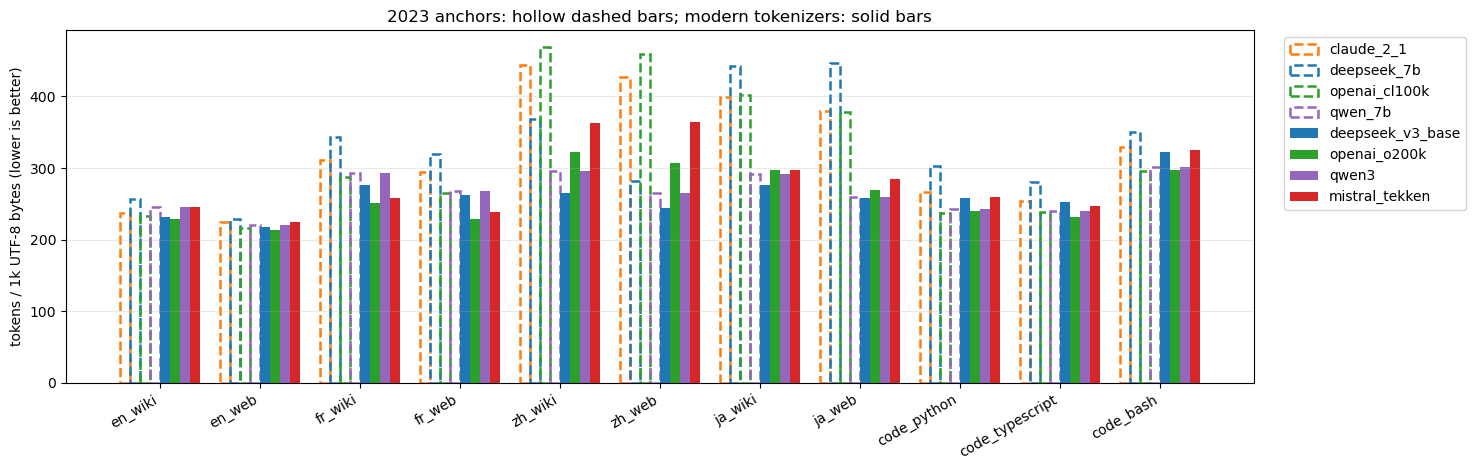

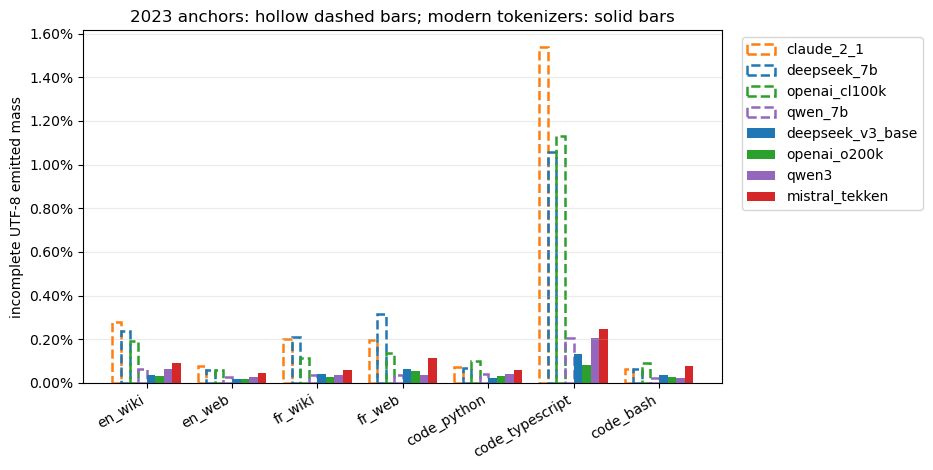

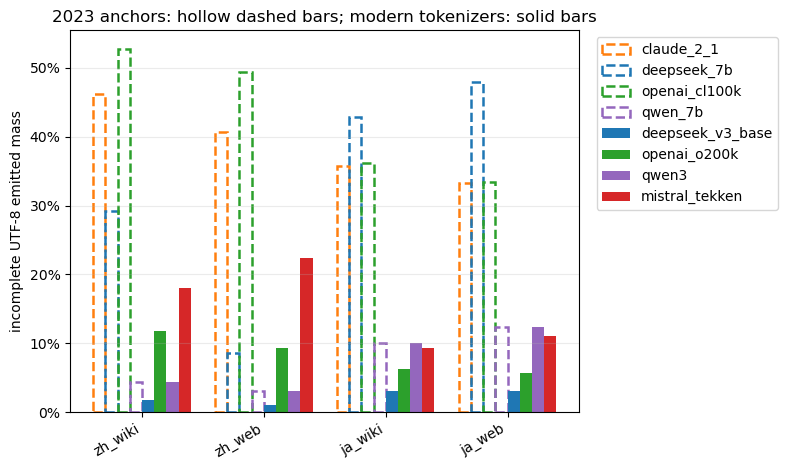

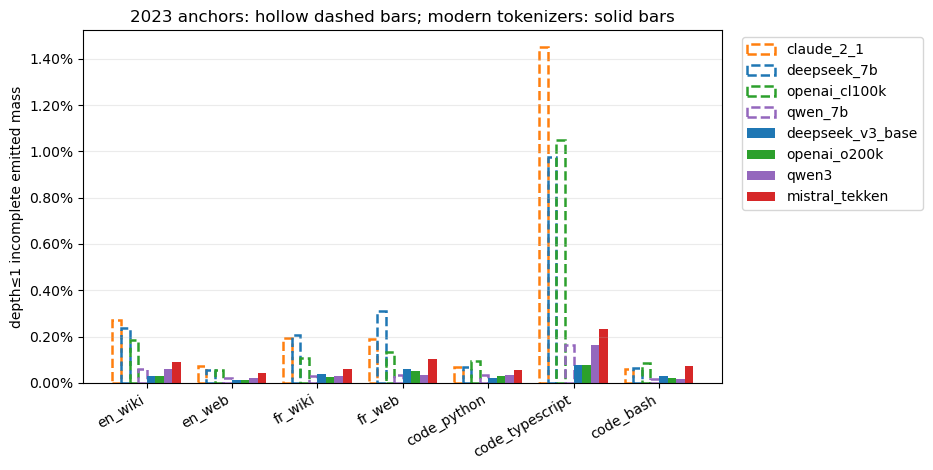

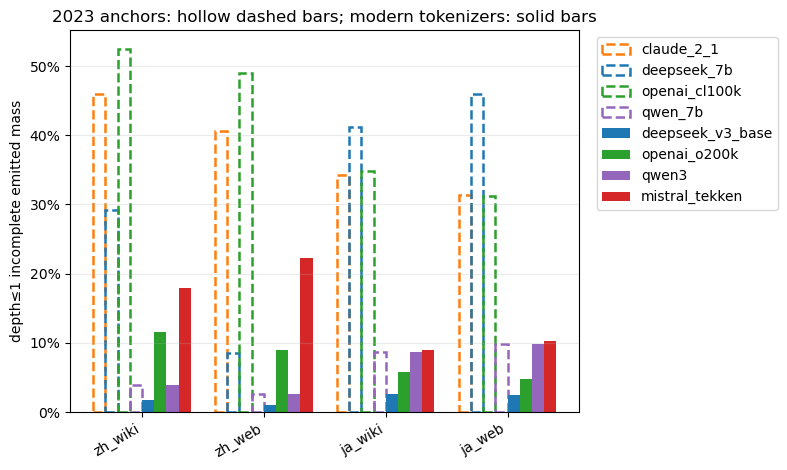

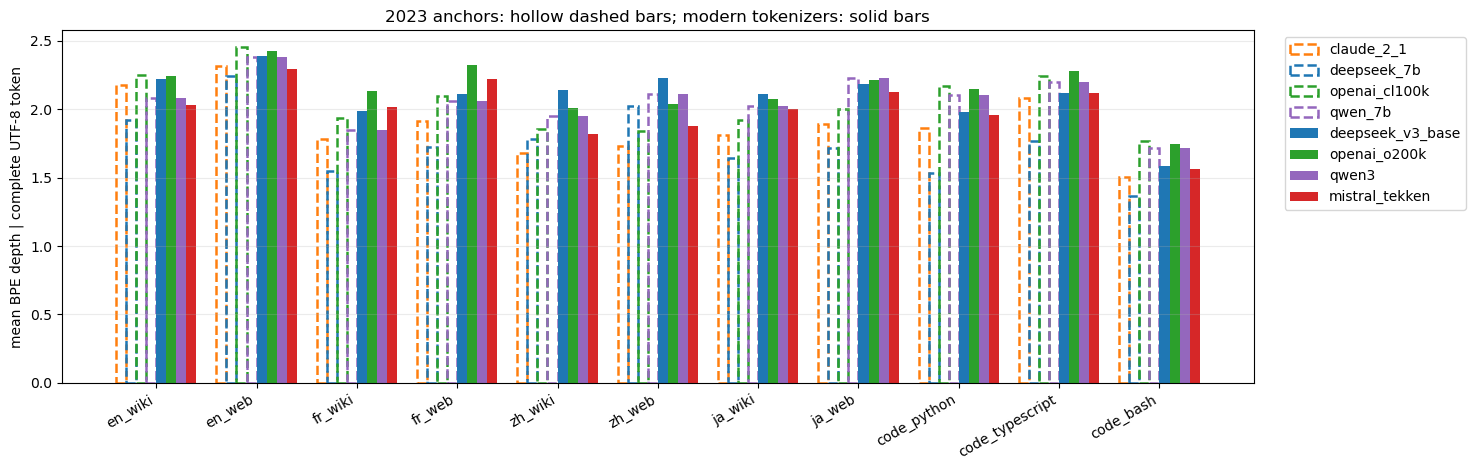

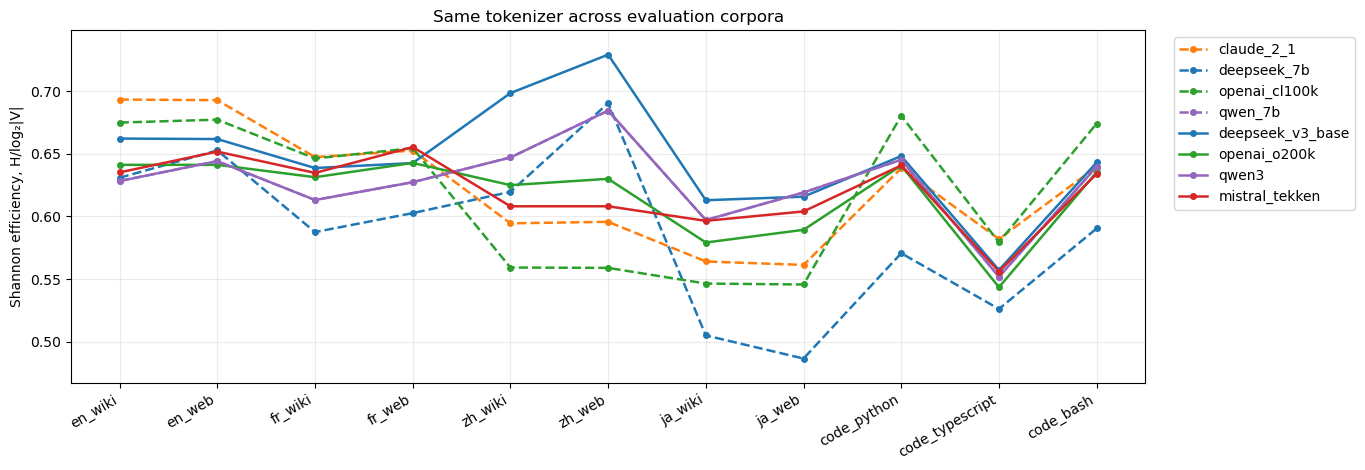

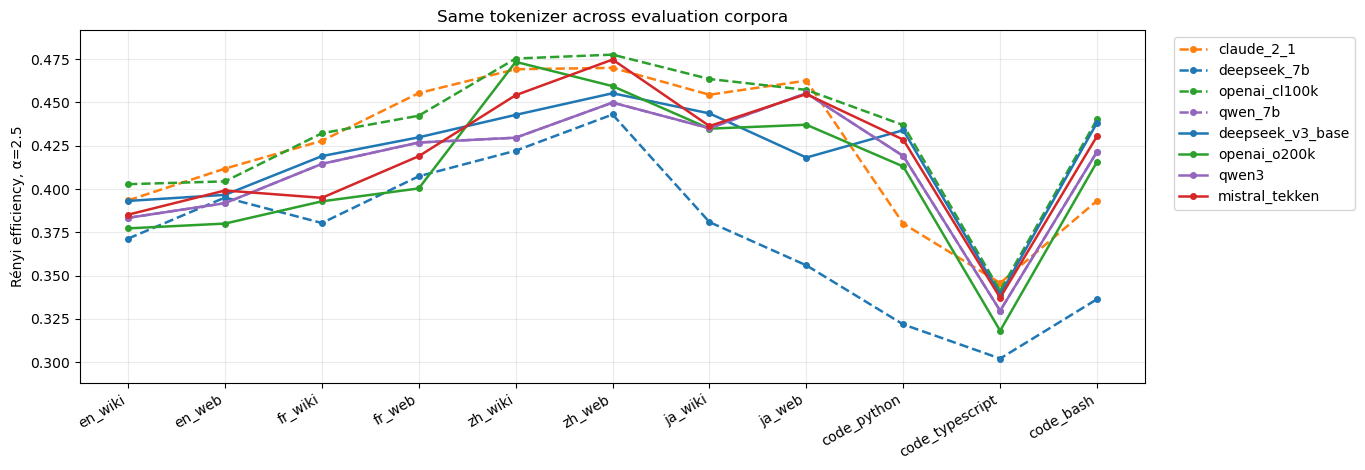

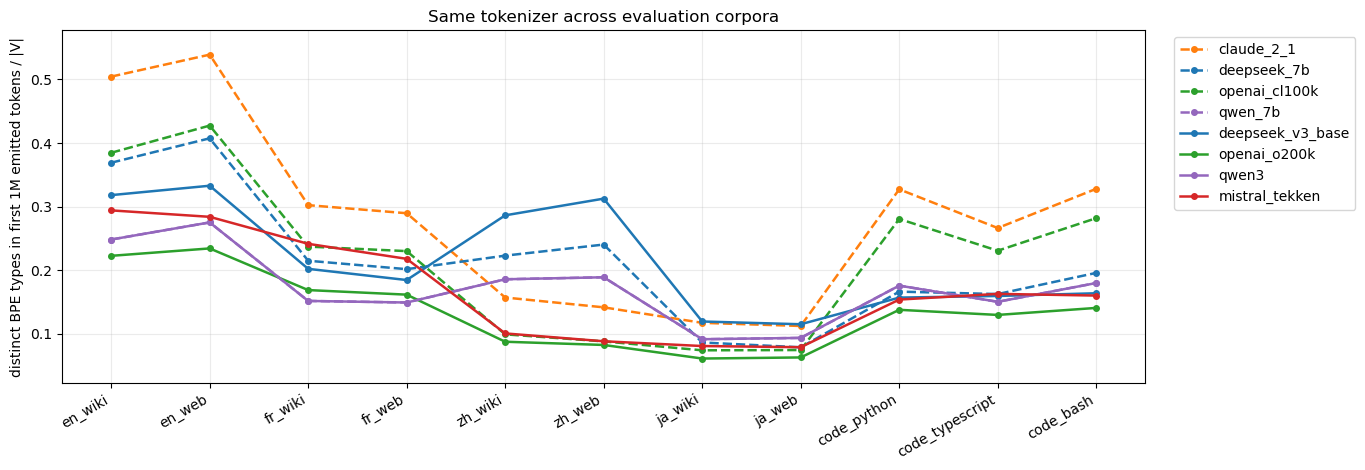

In [130]:
ANCHOR_2023 = {
    "deepseek_7b",
    "claude_2_1",
    "openai_cl100k",
    "qwen_7b",
}
PLOT_MODELS = (
    [name for name in canonical_models if name in ANCHOR_2023]
    + [name for name in canonical_models if name not in ANCHOR_2023]
)
# Claude 2.1作为统一的2023外部基准放在首位，Mistral Tekken放在最后。
PLOT_MODELS = (
    ["claude_2_1"]
    + [name for name in PLOT_MODELS if name not in {"claude_2_1", "mistral_tekken"}]
    + (["mistral_tekken"] if "mistral_tekken" in PLOT_MODELS else [])
)
FAMILY_COLORS = {
    "deepseek": "tab:blue",
    "claude": "tab:orange",
    "openai": "tab:green",
    "mistral": "tab:red",
    "qwen": "tab:purple",
}


def model_family(name):
    return "qwen" if name.startswith("qwen") else name.split("_", 1)[0]


COLORS = {name: FAMILY_COLORS[model_family(name)] for name in PLOT_MODELS}


def bar_plot(metric, ylabel, filename, cases=CASE_ORDER, percent=False):
    fig, axis = plt.subplots(figsize=(max(8, 1.35 * len(cases)), 4.8))
    x = np.arange(len(cases))
    width = 0.8 / len(PLOT_MODELS)
    values = pooled_df.set_index(["tokenizer", "case"])
    for index, name in enumerate(PLOT_MODELS):
        positions = x + (index - (len(PLOT_MODELS) - 1) / 2) * width
        style = (
            {
                "facecolor": "none",
                "edgecolor": COLORS[name],
                "linewidth": 1.8,
                "linestyle": "--",
            }
            if name in ANCHOR_2023
            else {"color": COLORS[name]}
        )
        axis.bar(
            positions,
            values.loc[(name, cases), metric].to_numpy(),
            width=width,
            label=MODEL_LABELS.get(name, name),
            **style,
        )
    axis.set_ylabel(ylabel)
    axis.set_xticks(x, cases, rotation=30, ha="right")
    axis.set_ylim(bottom=0)
    if percent:
        axis.yaxis.set_major_formatter(PercentFormatter(1))
    axis.grid(axis="y", alpha=0.25)
    axis.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    axis.set_title("2023 anchors: hollow dashed bars; modern tokenizers: solid bars")
    fig.tight_layout()
    fig.savefig(PLOT_DIR / filename, dpi=180, bbox_inches="tight")
    plt.show()


def stability_line(metric, ylabel, filename):
    fig, axis = plt.subplots(figsize=(max(9, 1.25 * len(CASE_ORDER)), 4.8))
    x = np.arange(len(CASE_ORDER))
    values = pooled_df.set_index(["tokenizer", "case"])
    metric_values = []
    for name in PLOT_MODELS:
        y = values.loc[(name, CASE_ORDER), metric].to_numpy()
        metric_values.extend(y)
        axis.plot(
            x,
            y,
            color=COLORS[name],
            linestyle="--" if name in ANCHOR_2023 else "-",
            marker="o",
            linewidth=1.8,
            markersize=4,
            label=MODEL_LABELS.get(name, name),
        )
    lower, upper = min(metric_values), max(metric_values)
    padding = 0.08 * (upper - lower) or 0.01
    axis.set_ylim(lower - padding, upper + padding)
    axis.set_ylabel(ylabel)
    axis.set_xticks(x, CASE_ORDER, rotation=30, ha="right")
    axis.grid(alpha=0.25)
    axis.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    axis.set_title("Same tokenizer across evaluation corpora")
    fig.tight_layout()
    fig.savefig(PLOT_DIR / filename, dpi=180, bbox_inches="tight")
    plt.show()


bar_plot(
    "tokens_per_1000_bytes",
    "tokens / 1k UTF-8 bytes (lower is better)",
    "compression_bytes.png",
)
NON_CJK_CASES = [
    case for case in CASE_ORDER if not case.startswith(("zh_", "ja_"))
]
CJK_CASES = ["zh_wiki", "zh_web", "ja_wiki", "ja_web"]
bar_plot(
    "incomplete_utf8_mass",
    "incomplete UTF-8 emitted mass",
    "fallback_incomplete_non_cjk.png",
    NON_CJK_CASES,
    percent=True,
)
bar_plot(
    "incomplete_utf8_mass",
    "incomplete UTF-8 emitted mass",
    "fallback_incomplete_cjk.png",
    CJK_CASES,
    percent=True,
)
bar_plot(
    "shallow_fallback_mass",
    "depth≤1 incomplete emitted mass",
    "fallback_shallow_non_cjk.png",
    NON_CJK_CASES,
    percent=True,
)
bar_plot(
    "shallow_fallback_mass",
    "depth≤1 incomplete emitted mass",
    "fallback_shallow_cjk.png",
    CJK_CASES,
    percent=True,
)
bar_plot(
    "complete_mean_depth",
    "mean BPE depth | complete UTF-8 token",
    "complete_mean_depth.png",
)
stability_line(
    "shannon_model_efficiency",
    "Shannon efficiency, H/log₂|V|",
    "shannon_efficiency_stability.png",
)
stability_line(
    "renyi_model_efficiency",
    "Rényi efficiency, α=2.5",
    "renyi_efficiency_stability.png",
)
stability_line(
    "standardized_active_ratio",
    "distinct BPE types in first 1M emitted tokens / |V|",
    "active_vocab_stability.png",
)


## 11. 图：UTF-8完整性优先的depth分布

English、French、Chinese、Japanese分别使用一张图，其中Wiki/Web是共享纵轴的并排子图；
Python/TypeScript/Bash组成一张Code图。横轴是互斥结构类别，纵轴是该类别在最终输出
token流中的probability mass，每个tokenizer一条线。
这组图已经同时表达fallback和depth，因此不再额外画一张重复的raw-depth图。
精确到每个depth的数值仍保存在`depth_distribution.csv`。下面按语言输出排名表；
自然语言的Wiki/Web两个case等权平均，不再分列。表中同时报告“失败比例”
`incomplete_utf8_mass`和只在完整BPE token上计算的`complete_mean_depth`。后者越高
表示成功输出更多来自较深merge，但不能脱离token长度和内容直接解释为质量更好。



English


,rank,tokenizer,incomplete_utf8_mass,complete_mean_depth
0,1,openai_cl100k,0.13%,2.351
1,2,openai_o200k,0.02%,2.336
2,3,deepseek_v3_base,0.03%,2.306
3,4,claude_2_1,0.18%,2.246
4,5,qwen_7b / qwen3,0.04%,2.230
5,6,mistral_tekken,0.07%,2.163
6,7,deepseek_7b,0.15%,2.082



French


,rank,tokenizer,incomplete_utf8_mass,complete_mean_depth
0,1,openai_o200k,0.04%,2.230
1,2,mistral_tekken,0.09%,2.120
2,3,deepseek_v3_base,0.05%,2.050
3,4,openai_cl100k,0.13%,2.015
4,5,qwen_7b / qwen3,0.04%,1.955
5,6,claude_2_1,0.20%,1.847
6,7,deepseek_7b,0.26%,1.634



Chinese


...

,rank,tokenizer,incomplete_utf8_mass,complete_mean_depth
0,1,openai_cl100k,0.10%,2.173
1,2,openai_o200k,0.03%,2.151
2,3,qwen_7b / qwen3,0.04%,2.106
3,4,deepseek_v3_base,0.02%,1.980
4,5,mistral_tekken,0.06%,1.956
5,6,claude_2_1,0.07%,1.863
6,7,deepseek_7b,0.07%,1.533



TypeScript


,rank,tokenizer,incomplete_utf8_mass,complete_mean_depth
0,1,openai_o200k,0.08%,2.282
1,2,openai_cl100k,1.13%,2.240
2,3,qwen_7b / qwen3,0.21%,2.198
3,4,mistral_tekken,0.24%,2.120
4,5,deepseek_v3_base,0.13%,2.118
5,6,claude_2_1,1.54%,2.084
6,7,deepseek_7b,1.06%,1.766



Bash


,rank,tokenizer,incomplete_utf8_mass,complete_mean_depth
0,1,openai_cl100k,0.09%,1.771
1,2,openai_o200k,0.02%,1.745
2,3,qwen_7b / qwen3,0.02%,1.714
3,4,deepseek_v3_base,0.03%,1.588
4,5,mistral_tekken,0.08%,1.561
5,6,claude_2_1,0.06%,1.508
6,7,deepseek_7b,0.07%,1.364


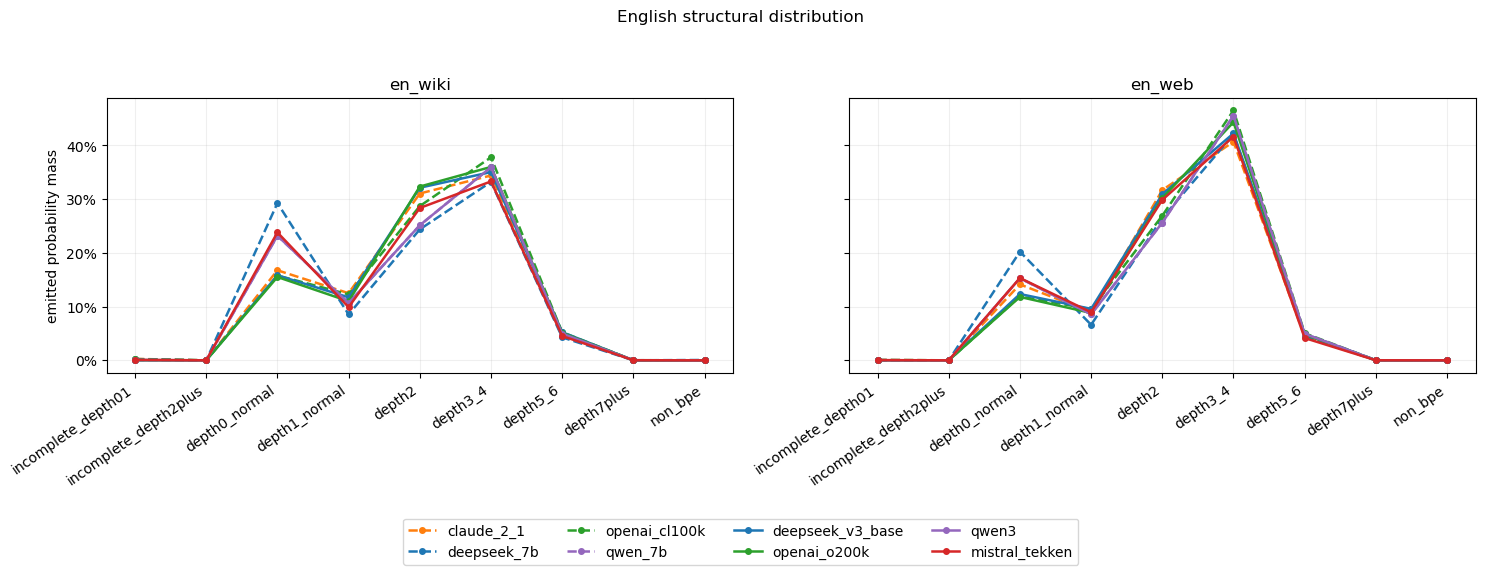

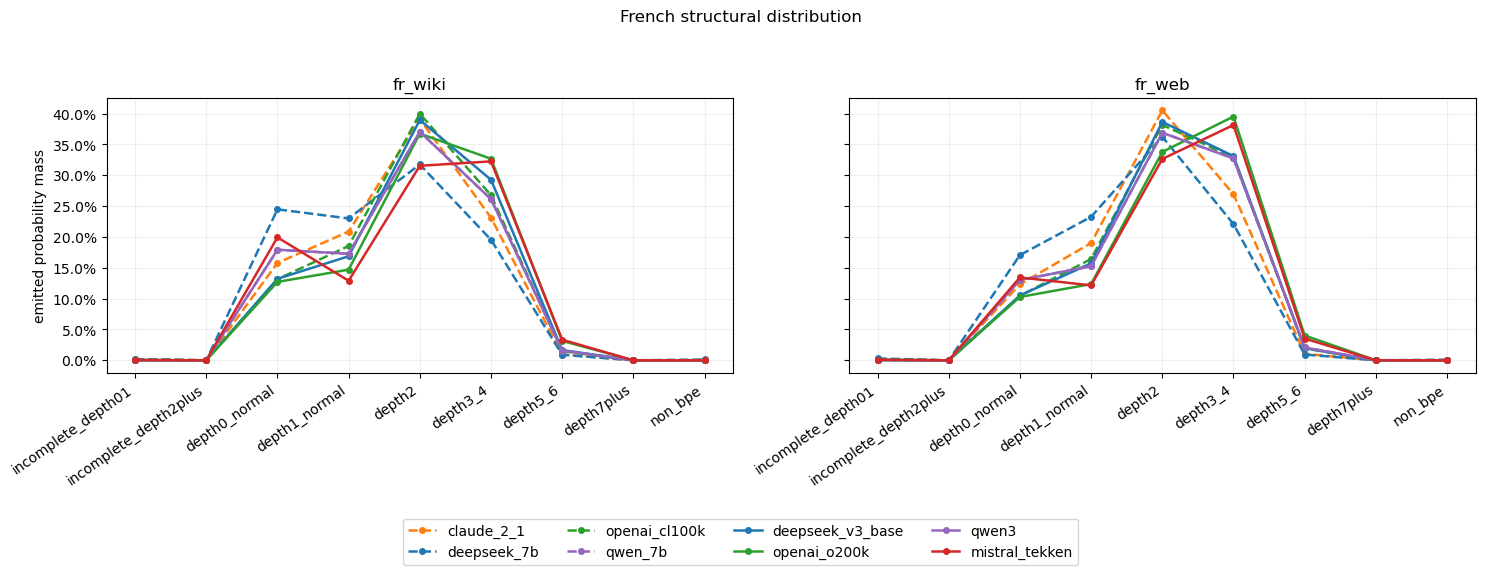

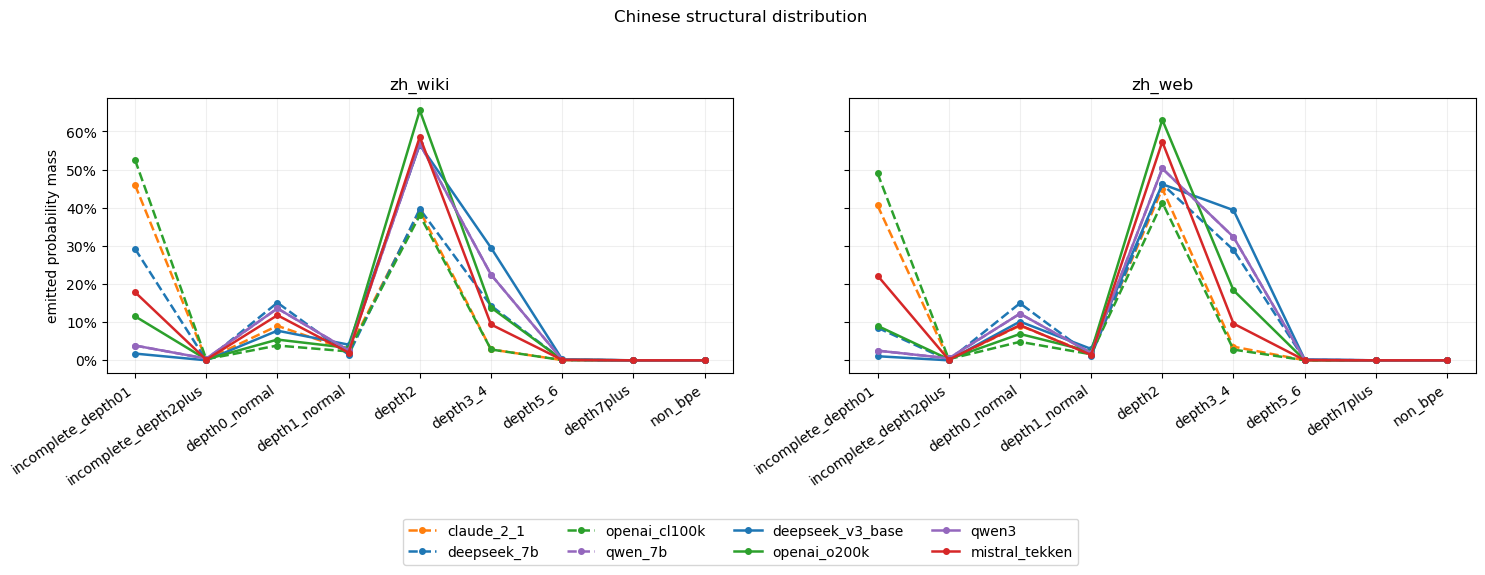

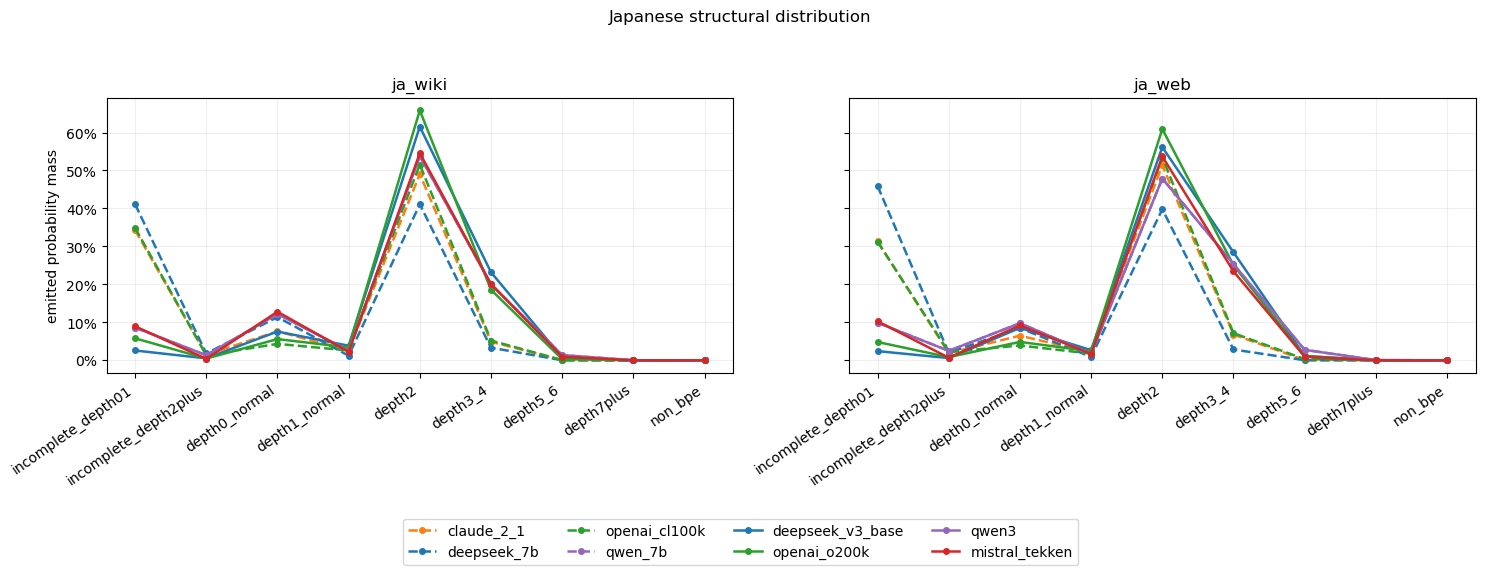

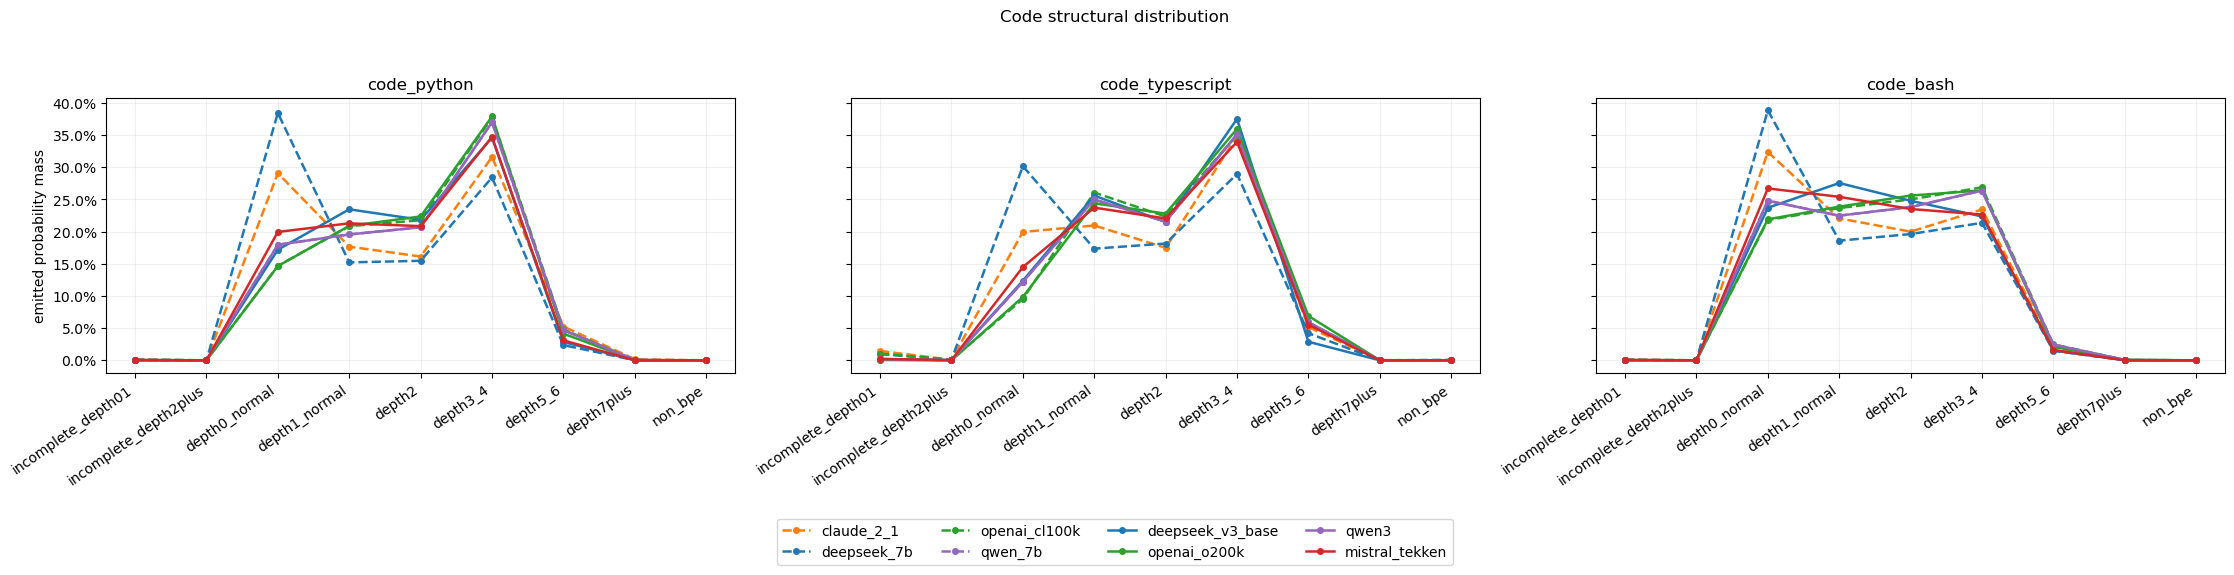

In [131]:
DEPTH_DISPLAY_ITEMS = [
    (name, name)
    for name in canonical_models
    if name not in {"qwen_7b", "qwen3", "mistral_tekken"}
]
if "qwen_7b" in canonical_models:
    DEPTH_DISPLAY_ITEMS.append(("qwen_7b / qwen3", "qwen_7b"))
if "mistral_tekken" in canonical_models:
    DEPTH_DISPLAY_ITEMS.append(("mistral_tekken", "mistral_tekken"))
depth_values = pooled_df.set_index(["tokenizer", "case"])

def display_depth_ranking(language, cases):
    rows = []
    for label, name in DEPTH_DISPLAY_ITEMS:
        values = depth_values.loc[[(name, case) for case in cases]]
        rows.append(
            {
                "tokenizer": label,
                "incomplete_utf8_mass": values["incomplete_utf8_mass"].mean(),
                "complete_mean_depth": values["complete_mean_depth"].mean(),
            }
        )
    ranking = pd.DataFrame(rows).sort_values(
        "complete_mean_depth", ascending=False
    ).reset_index(drop=True)
    ranking.insert(0, "rank", np.arange(1, len(ranking) + 1))
    print(f"\n{language}")
    display(
        ranking.style.format(
            {
                "incomplete_utf8_mass": "{:.2%}",
                "complete_mean_depth": "{:.3f}",
            }
        )
    )


for language, cases in (
    ("English", ["en_web", "en_wiki"]),
    ("French", ["fr_web", "fr_wiki"]),
    ("Chinese", ["zh_web", "zh_wiki"]),
    ("Japanese", ["ja_web", "ja_wiki"]),
    ("Python", ["code_python"]),
    ("TypeScript", ["code_typescript"]),
    ("Bash", ["code_bash"]),
):
    display_depth_ranking(language, cases)

pooled_structure = structure_df[structure_df["shard"] == "pooled"]
x = np.arange(len(STRUCTURE_ORDER))


def structural_figure(cases, title, filename):
    fig, axes = plt.subplots(
        1,
        len(cases),
        figsize=(7.5 * len(cases), 5.8),
        sharey=True,
        squeeze=False,
    )
    for axis, case in zip(axes[0], cases):
        table = (
            pooled_structure[pooled_structure["case"] == case]
            .pivot(index="tokenizer", columns="structural_class", values="probability_mass")
            .reindex(index=PLOT_MODELS, columns=STRUCTURE_ORDER, fill_value=0)
        )
        for name in PLOT_MODELS:
            axis.plot(
                x,
                table.loc[name].to_numpy(),
                color=COLORS[name],
                linestyle="--" if name in ANCHOR_2023 else "-",
                marker="o",
                linewidth=1.8,
                markersize=4,
                label=MODEL_LABELS.get(name, name),
            )
        axis.set_title(case)
        axis.set_xticks(x, STRUCTURE_ORDER, rotation=35, ha="right")
        axis.yaxis.set_major_formatter(PercentFormatter(1))
        axis.grid(alpha=0.2)
    axes[0, 0].set_ylabel("emitted probability mass")
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=4, bbox_to_anchor=(0.5, 0.01))
    fig.suptitle(title)
    fig.tight_layout(rect=(0, 0.13, 1, 0.94))
    fig.savefig(PLOT_DIR / filename, dpi=180, bbox_inches="tight")
    plt.show()


structural_figure(["en_wiki", "en_web"], "English structural distribution", "structural_classes_en.png")
structural_figure(["fr_wiki", "fr_web"], "French structural distribution", "structural_classes_fr.png")
structural_figure(["zh_wiki", "zh_web"], "Chinese structural distribution", "structural_classes_zh.png")
structural_figure(["ja_wiki", "ja_web"], "Japanese structural distribution", "structural_classes_ja.png")
structural_figure(
    ["code_python", "code_typescript", "code_bash"],
    "Code structural distribution",
    "structural_classes_code.png",
)
